# EDA: correlation and per-column interpretation

Full processed panel (`data/processed/wem_5min_panel.parquet`) for MATH5001.

This notebook is the interactive version of `scripts/explore_panel.py`. The script writes figures and a written report to `reports/eda/`.

Run order: load → missingness/univariate → Pearson/Spearman heatmaps → each column vs MCP → calendar → collinearity → per-column notes.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

candidates = [
    Path("data/processed/wem_5min_panel.parquet"),
    Path("../data/processed/wem_5min_panel.parquet"),
]
panel_path = next(p for p in candidates if p.exists())
df = pd.read_parquet(panel_path, engine="pyarrow")
df["interval_end"] = pd.to_datetime(df["interval_end"])
df["trading_interval_end"] = pd.to_datetime(df["trading_interval_end"])
df = df.sort_values("interval_end").reset_index(drop=True)
print(panel_path.resolve())
print(f"rows={len(df):,}  cols={df.shape[1]}")
print(df["interval_end"].min(), "→", df["interval_end"].max())
df.head()

/Users/jg/Documents/MATH5001 Project/data/processed/wem_5min_panel.parquet
rows=302,964  cols=33
2023-10-01 08:00:00 → 2026-08-18 07:55:00


,interval_end,mcp,cr_raise,cr_lower,reg_raise,reg_lower,rocof,operational_demand_mw,unscheduled_demand_mw,operational_withdrawal_mw,...,residual_demand_mw,mcp_lag1,mcp_lag6,mcp_lag12,hour,minute,dow,month,year,is_weekend
0,2023-10-01 08:00:00,738.00,1180.27,0.49,577.15,0.5,0.0,1606.73,1598.12,-8.61,...,1191.34,NaN,NaN,NaN,8,0,6,10,2023,True
1,2023-10-01 08:05:00,738.00,1107.77,0.49,577.15,0.5,0.0,1594.24,1586.53,-7.71,...,1166.33,738.0,NaN,NaN,8,5,6,10,2023,True
2,2023-10-01 08:10:00,738.00,689.17,0.10,575.44,0.5,0.0,1581.83,1574.04,-7.79,...,1121.34,738.0,NaN,NaN,8,10,6,10,2023,True
3,2023-10-01 08:15:00,738.00,684.83,0.10,575.44,0.5,0.0,1554.51,1547.28,-7.23,...,1068.45,738.0,NaN,NaN,8,15,6,10,2023,True
4,2023-10-01 08:20:00,263.54,190.69,0.10,104.88,0.5,0.0,1524.89,1517.86,-7.03,...,1031.22,738.0,NaN,NaN,8,20,6,10,2023,True


## Numeric frame

Drop the two timestamps. Map `is_weekend` to 0/1 so it can enter the correlation matrix.

In [2]:
num = df.drop(columns=["interval_end", "trading_interval_end"]).copy()
num["is_weekend"] = num["is_weekend"].astype(int)
num = num.select_dtypes(include=[np.number])
print("numeric columns:", list(num.columns))
print()
print("missing share (%)")
print((df.isna().mean() * 100).sort_values(ascending=False).round(3).to_string())

numeric columns: ['mcp', 'cr_raise', 'cr_lower', 'reg_raise', 'reg_lower', 'rocof', 'operational_demand_mw', 'unscheduled_demand_mw', 'operational_withdrawal_mw', 'dpv_mw', 'rtp', 'stem_price', 'stem_qty_mwh', 'stem_bid_mwh', 'stem_offer_mwh', 'sent_out_mwh', 'sent_out_mw', 'dpv_mw_30min', 'scada_mwh', 'scada_mw', 'scheduled_energy_mw', 'residual_demand_mw', 'mcp_lag1', 'mcp_lag6', 'mcp_lag12', 'hour', 'minute', 'dow', 'month', 'year', 'is_weekend']

missing share (%)
dpv_mw_30min                 5.135
sent_out_mwh                 2.853
sent_out_mw                  2.853
mcp_lag12                    0.004
mcp_lag6                     0.002
rtp                          0.002
residual_demand_mw           0.000
dpv_mw                       0.000
mcp_lag1                     0.000
hour                         0.000
minute                       0.000
dow                          0.000
month                        0.000
scheduled_energy_mw          0.000
scada_mw                     0.000
sc

## Target: MCP distribution

Energy prices are spike-heavy. The right-hand plot clips to the 1st–99th percentile so the body of the distribution is visible.

count    302964.000000
mean         88.967999
std         112.920789
min       -1000.000000
1%          -61.220000
5%          -44.210000
50%          91.010000
95%         166.990000
99%         738.000000
max        1100.000000
skew=1.06  kurtosis=34.3  share<0=12.92%


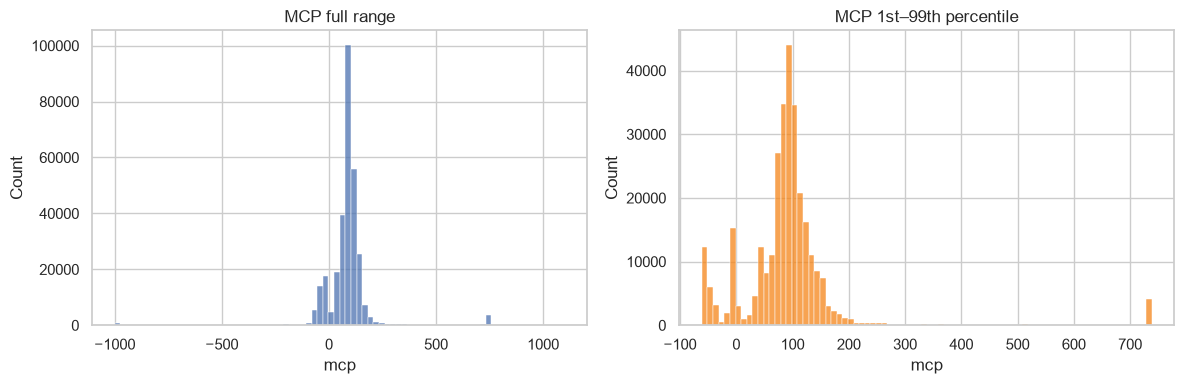

In [3]:
y = df["mcp"]
print(y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())
print(f"skew={y.skew():.2f}  kurtosis={y.kurtosis():.1f}  share<0={(y < 0).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, bins=80, ax=axes[0])
axes[0].set_title("MCP full range")
lo, hi = y.quantile([0.01, 0.99])
sns.histplot(y.clip(lo, hi), bins=80, ax=axes[1], color="#F58518")
axes[1].set_title("MCP 1st–99th percentile")
plt.tight_layout()

## Pearson and Spearman correlation

- **Pearson** finds linear collinearity (demand vs SCADA vs scheduled vs sent-out).
- **Spearman** is the right ranking against MCP because of spikes.

Exact identities in this panel (do not put both sides in a linear model):

- `sent_out_mw = 2 × sent_out_mwh`
- `scada_mw = 12 × scada_mwh`
- `residual_demand_mw = operational_demand_mw − dpv_mw`
- `is_weekend = (dow ≥ 5)`

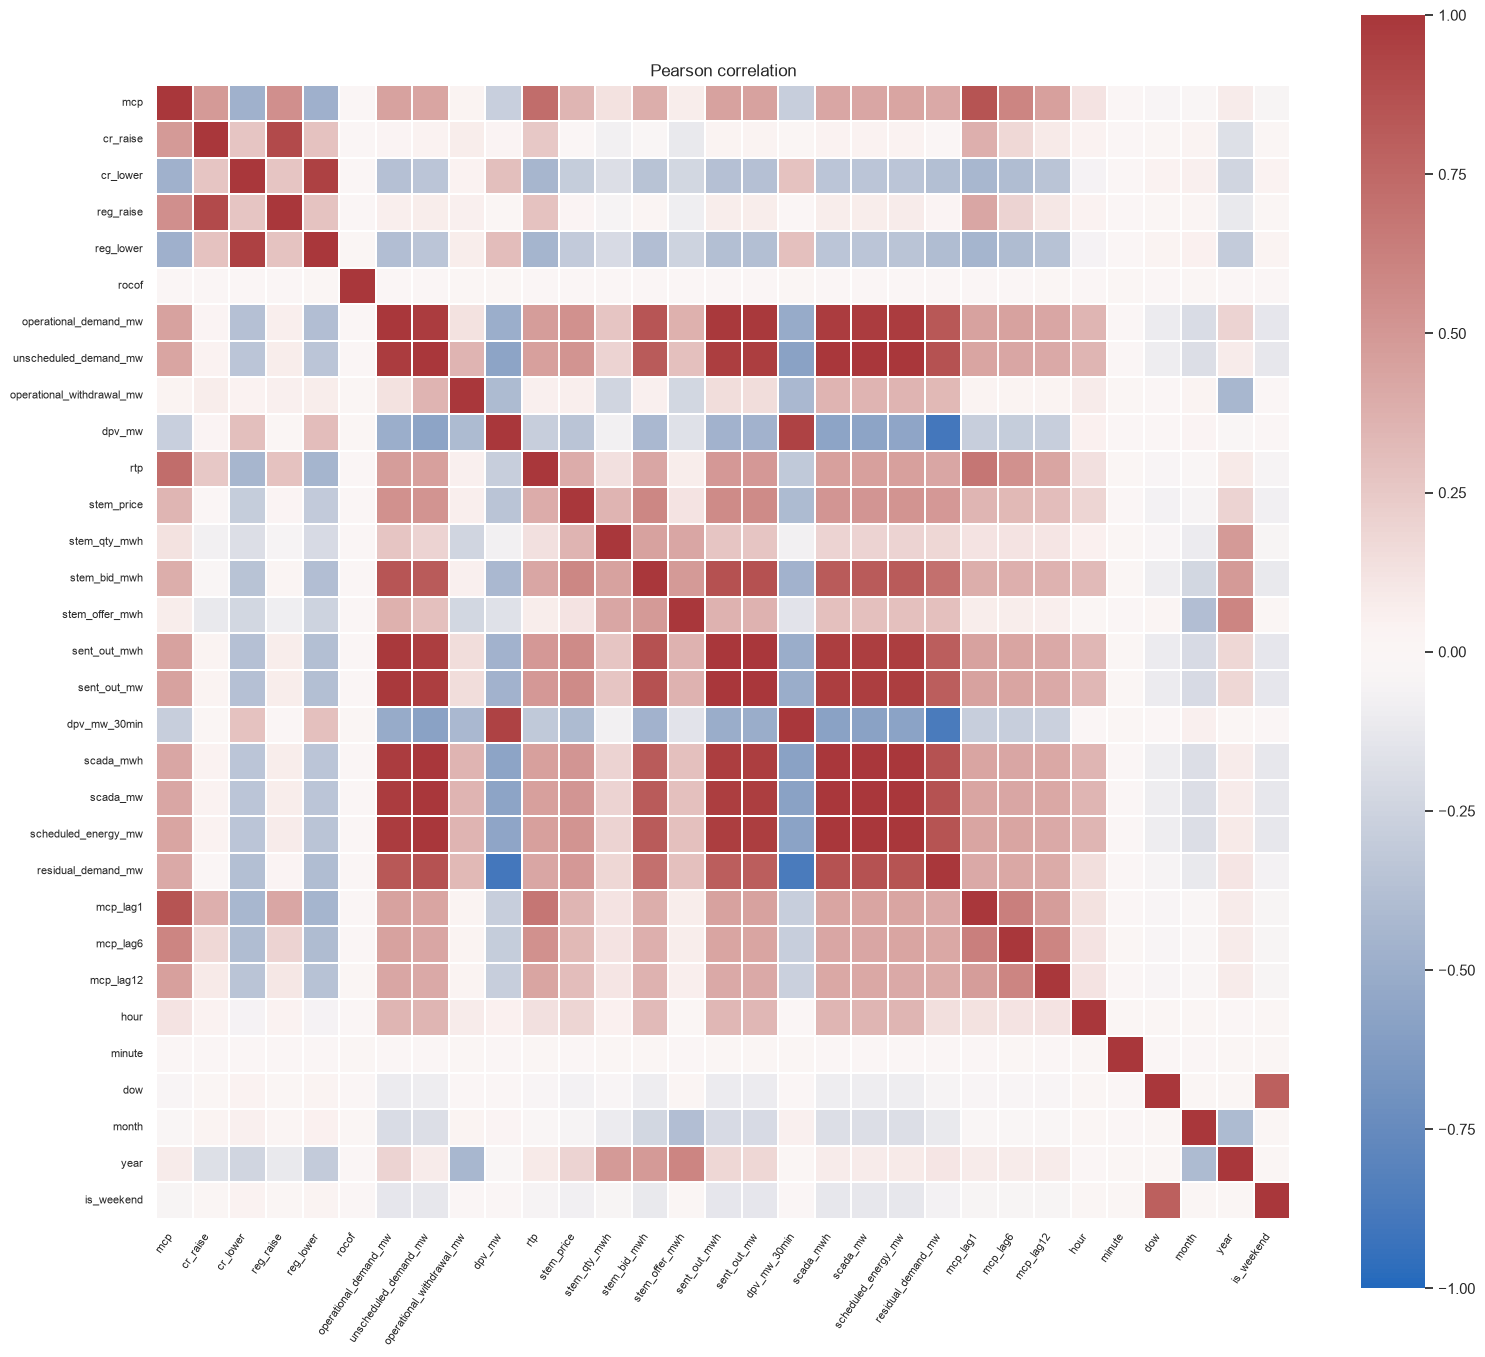

In [4]:
pearson = num.corr(method="pearson")
spearman = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(pearson, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.2)
ax.set_title("Pearson correlation")
plt.xticks(rotation=55, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

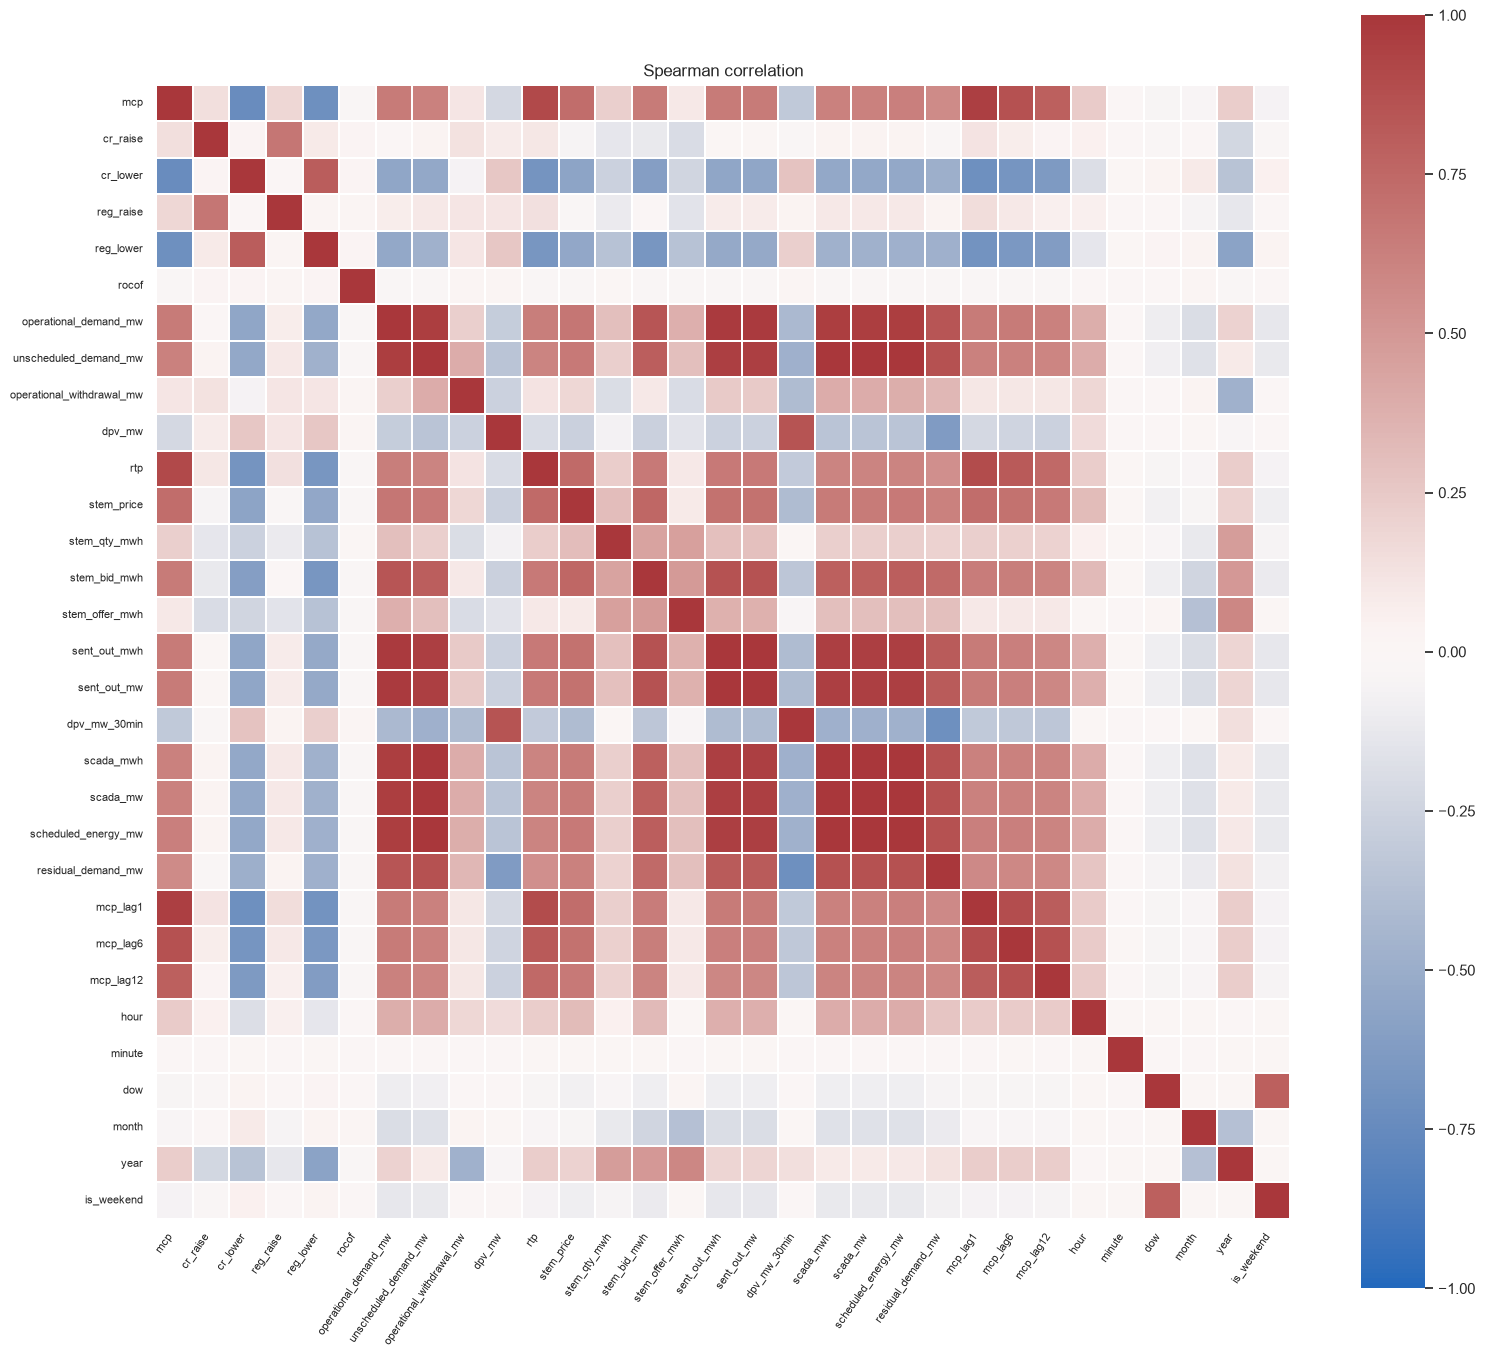

In [5]:
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(spearman, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.2)
ax.set_title("Spearman correlation")
plt.xticks(rotation=55, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()

## Each numeric column vs MCP

,pearson,spearman
mcp_lag1,0.854,0.957
rtp,0.725,0.908
mcp_lag6,0.596,0.873
mcp_lag12,0.459,0.795
cr_lower,-0.472,-0.739
stem_price,0.349,0.723
reg_lower,-0.481,-0.713
sent_out_mwh,0.448,0.652
sent_out_mw,0.448,0.652
operational_demand_mw,0.448,0.650


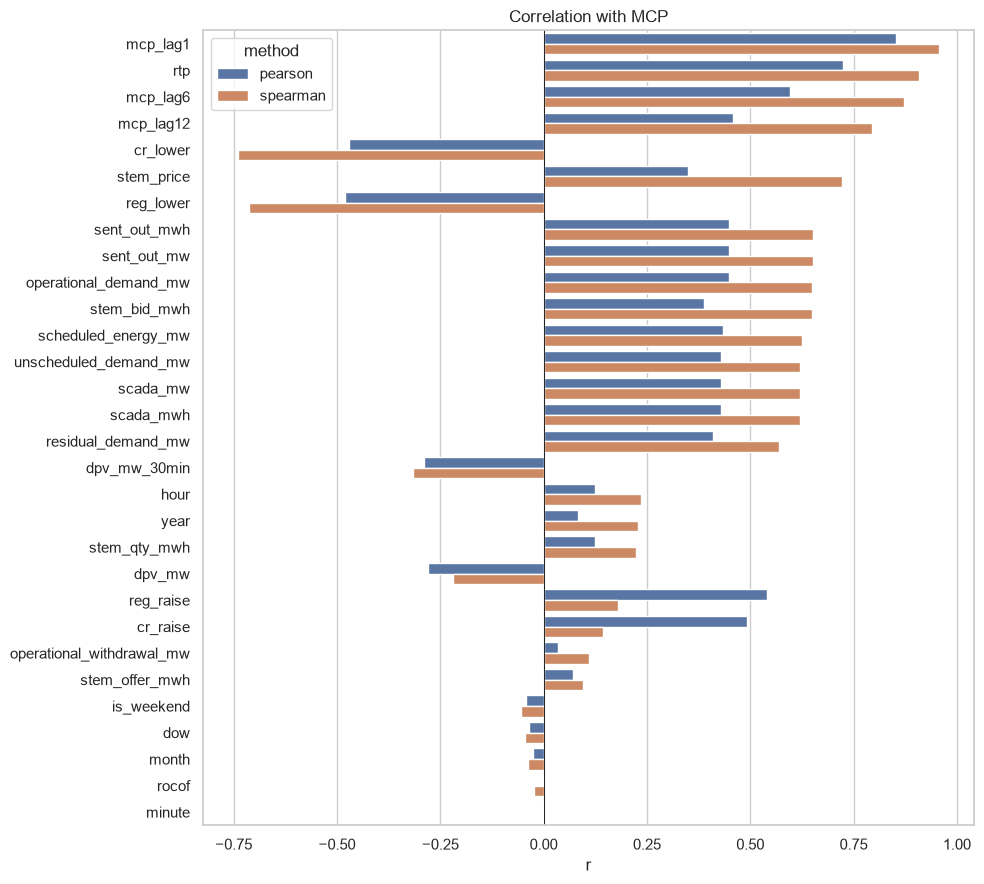

In [6]:
vs = pd.DataFrame({
    "pearson": pearson["mcp"].drop("mcp"),
    "spearman": spearman["mcp"].drop("mcp"),
}).sort_values("spearman", key=lambda s: s.abs(), ascending=False)
display(vs.style.format("{:.3f}").background_gradient(cmap="vlag", vmin=-1, vmax=1))

long = vs.reset_index().melt(id_vars="index", var_name="method", value_name="r")
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=long, y="index", x="r", hue="method", ax=ax)
ax.axvline(0, color="black", lw=0.6)
ax.set_ylabel("")
ax.set_title("Correlation with MCP")
plt.tight_layout()

## Univariate distributions

Continuous columns are clipped to 0.5–99.5 percentile so a handful of price spikes do not flatten the histogram. Calendar columns are count plots.

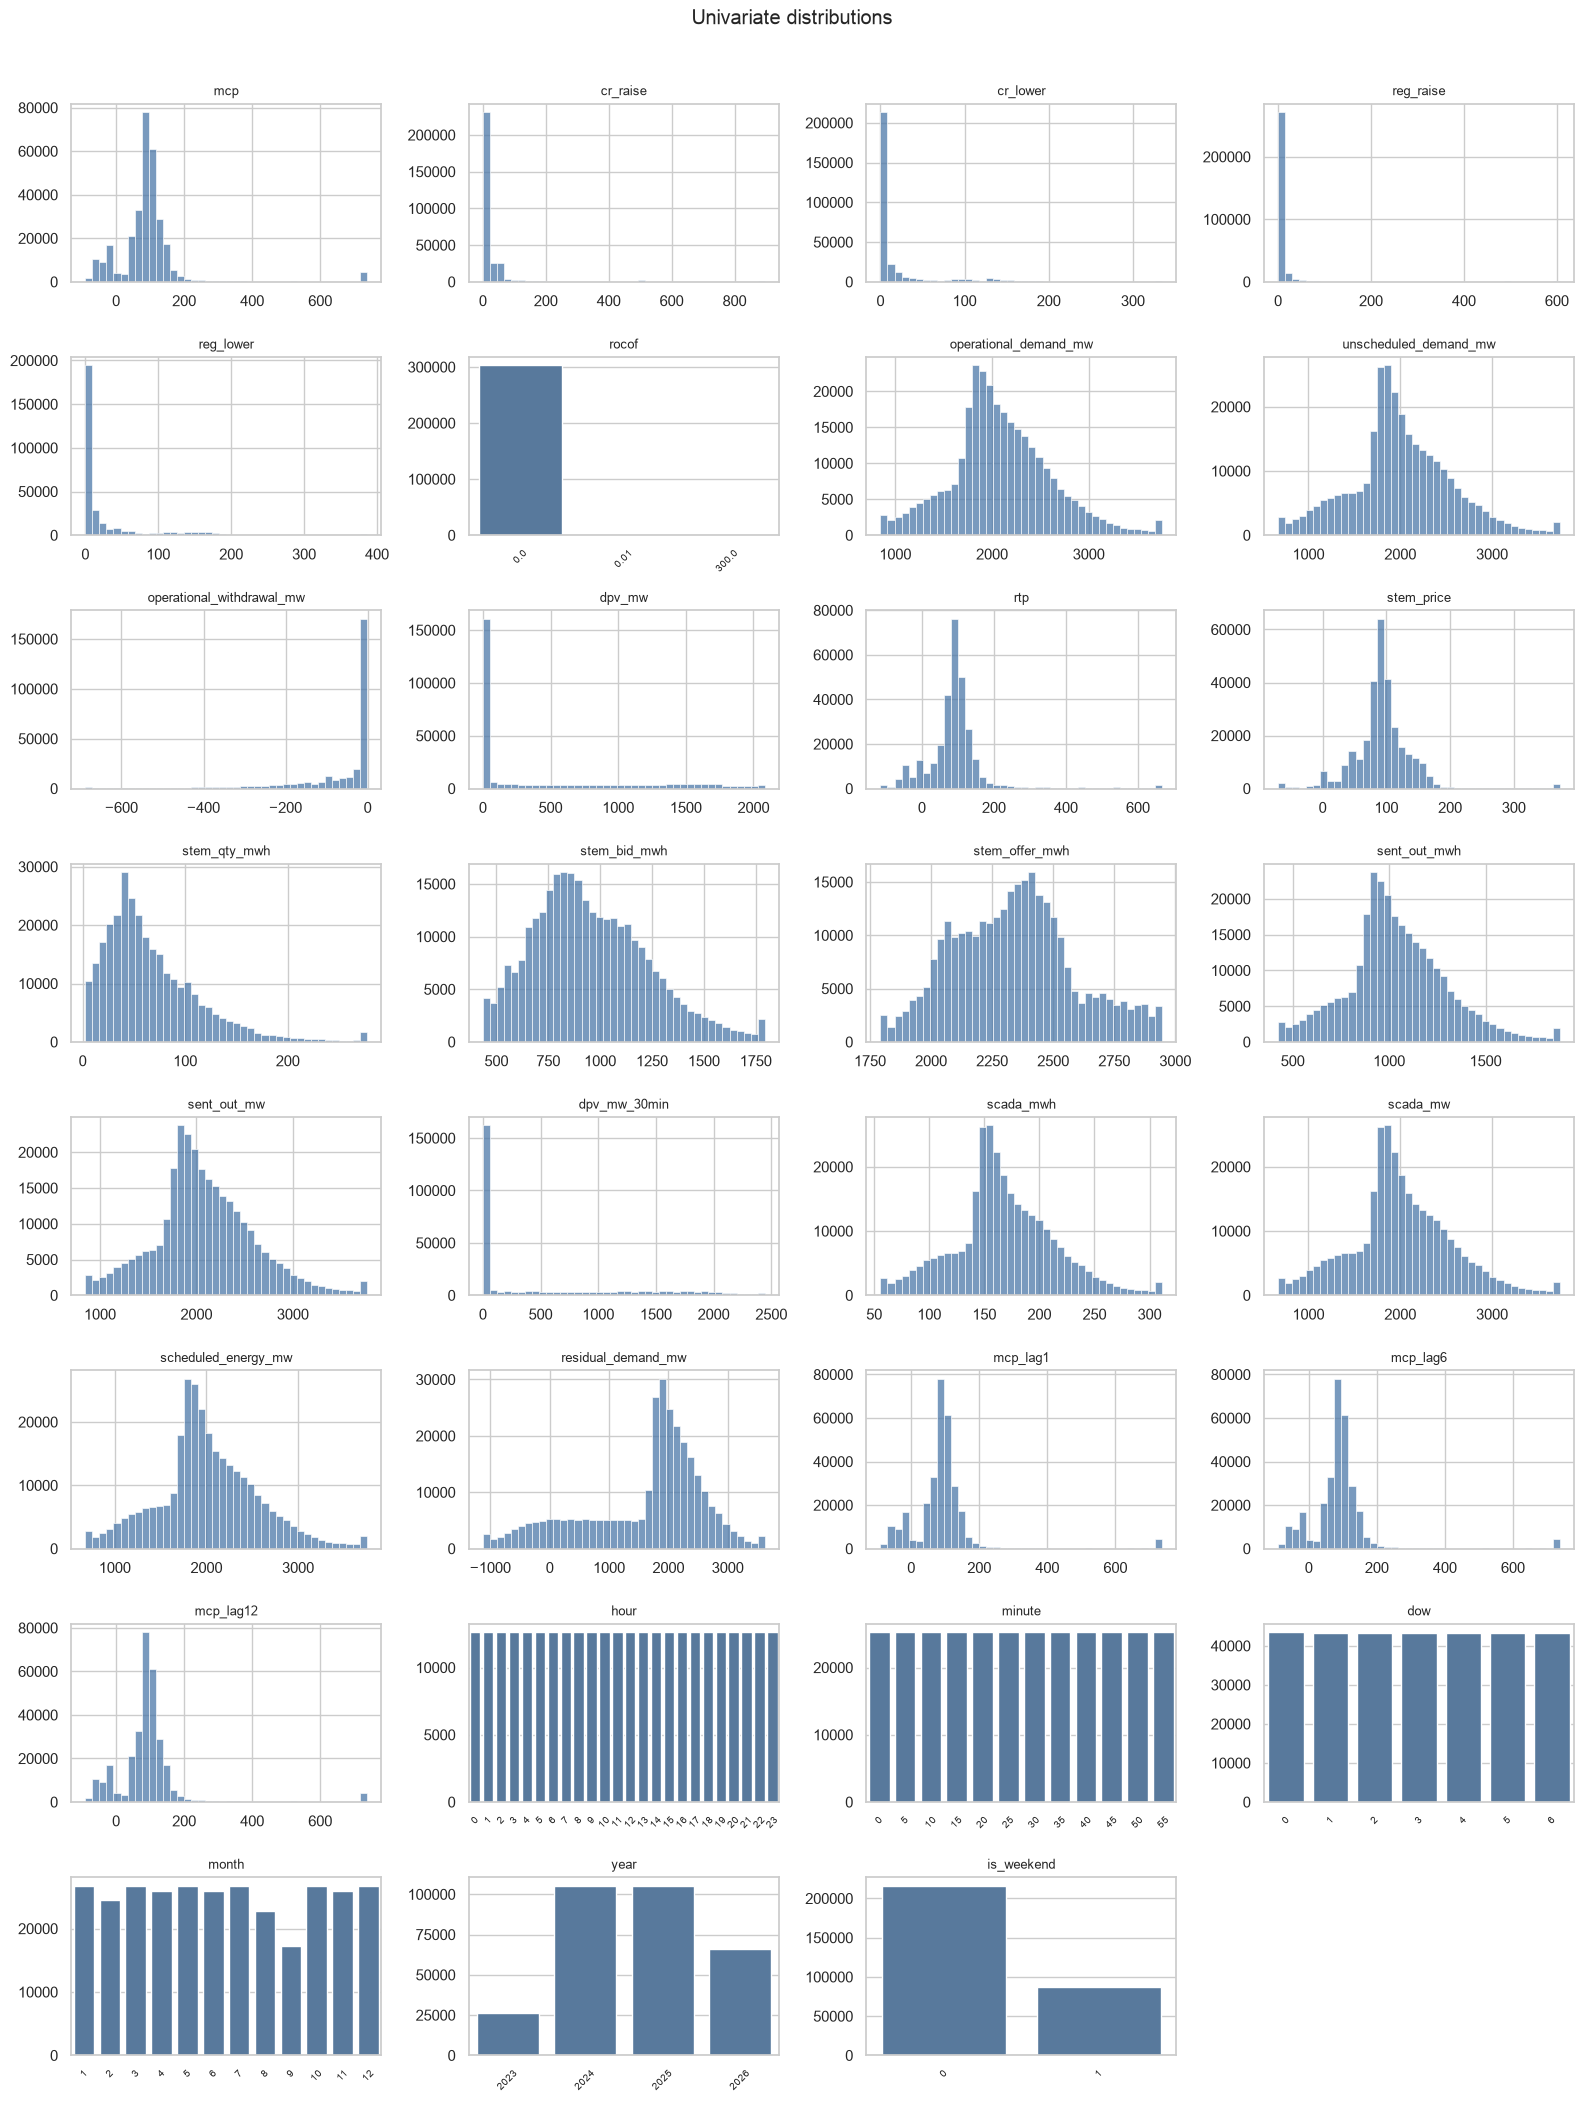

In [7]:
cols = list(num.columns)
ncols = 4
nrows = int(np.ceil(len(cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 2.6 * nrows))
axes = np.ravel(axes)
for i, col in enumerate(cols):
    ax = axes[i]
    s = num[col].dropna()
    if s.nunique() <= 24:
        sns.countplot(x=s, order=np.sort(s.unique()), ax=ax, color="#4C78A8")
        ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    else:
        lo, hi = s.quantile([0.005, 0.995])
        sns.histplot(s.clip(lo, hi), bins=40, ax=ax, color="#4C78A8")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()
fig.suptitle("Univariate distributions", y=1.01)
plt.tight_layout()

## Calendar structure of MCP

Diurnal (hour), weekly (dow / weekend), and seasonal (month) effects. Outliers are hidden in the boxplots so the body of the distribution is readable; the spikes still exist.

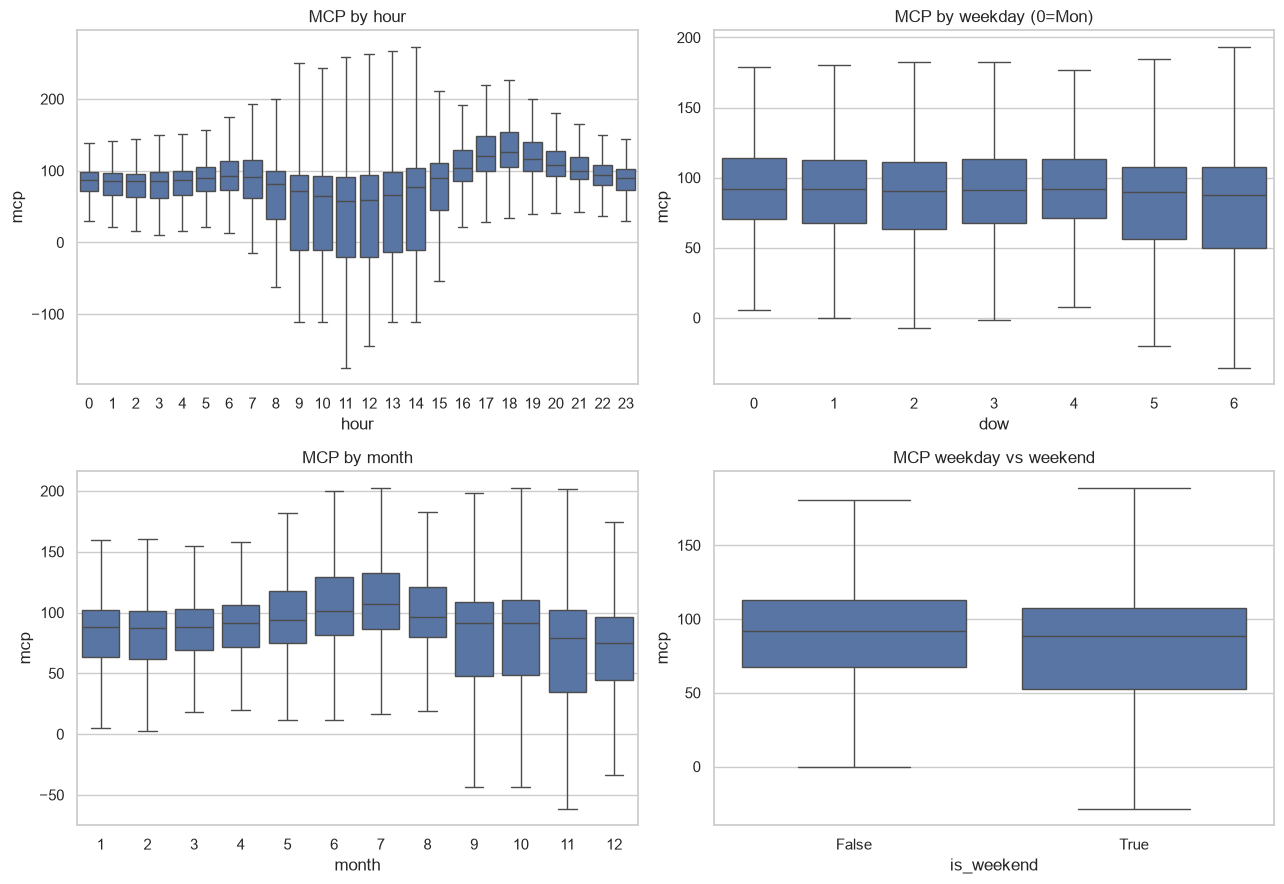

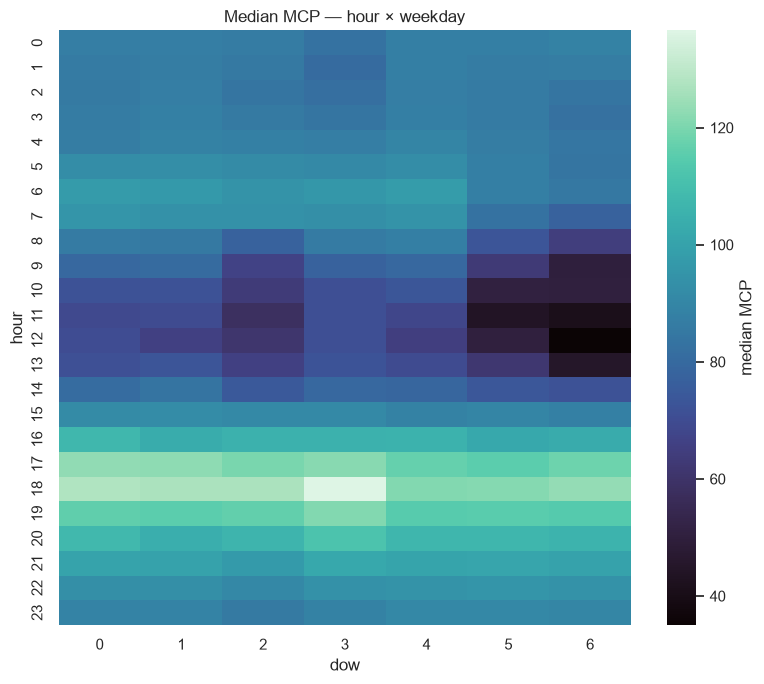

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=df, x="hour", y="mcp", ax=axes[0, 0], showfliers=False)
axes[0, 0].set_title("MCP by hour")
sns.boxplot(data=df, x="dow", y="mcp", ax=axes[0, 1], showfliers=False)
axes[0, 1].set_title("MCP by weekday (0=Mon)")
sns.boxplot(data=df, x="month", y="mcp", ax=axes[1, 0], showfliers=False)
axes[1, 0].set_title("MCP by month")
sns.boxplot(data=df, x="is_weekend", y="mcp", ax=axes[1, 1], showfliers=False)
axes[1, 1].set_title("MCP weekday vs weekend")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df.pivot_table(index="hour", columns="dow", values="mcp", aggfunc="median"),
            ax=ax, cmap="mako", cbar_kws={"label": "median MCP"})
ax.set_title("Median MCP — hour × weekday")
plt.tight_layout()

## Key fundamentals vs MCP

20k-row sample for scatter; pairplot uses 4k so it stays readable. Same-interval `rtp` is shown as a leakage diagnostic, not as a valid predictor.

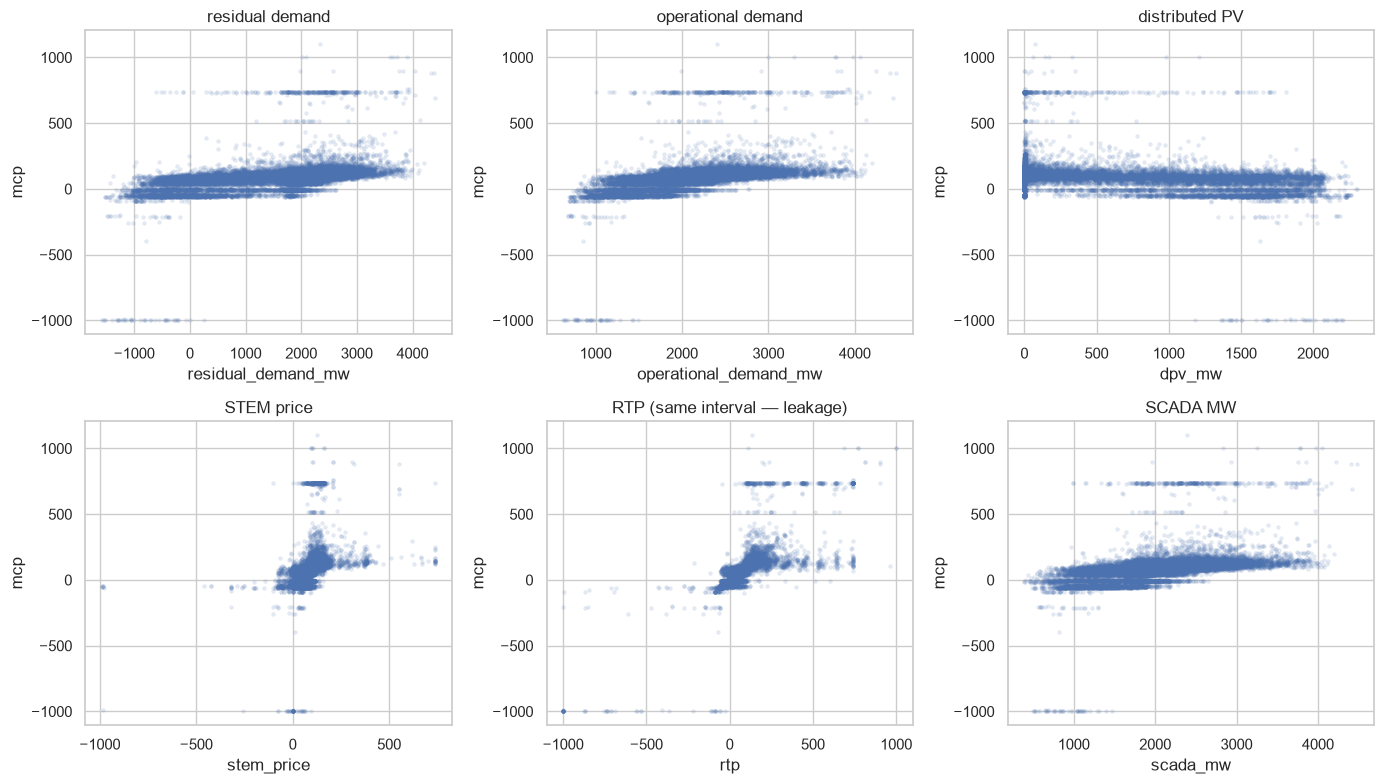

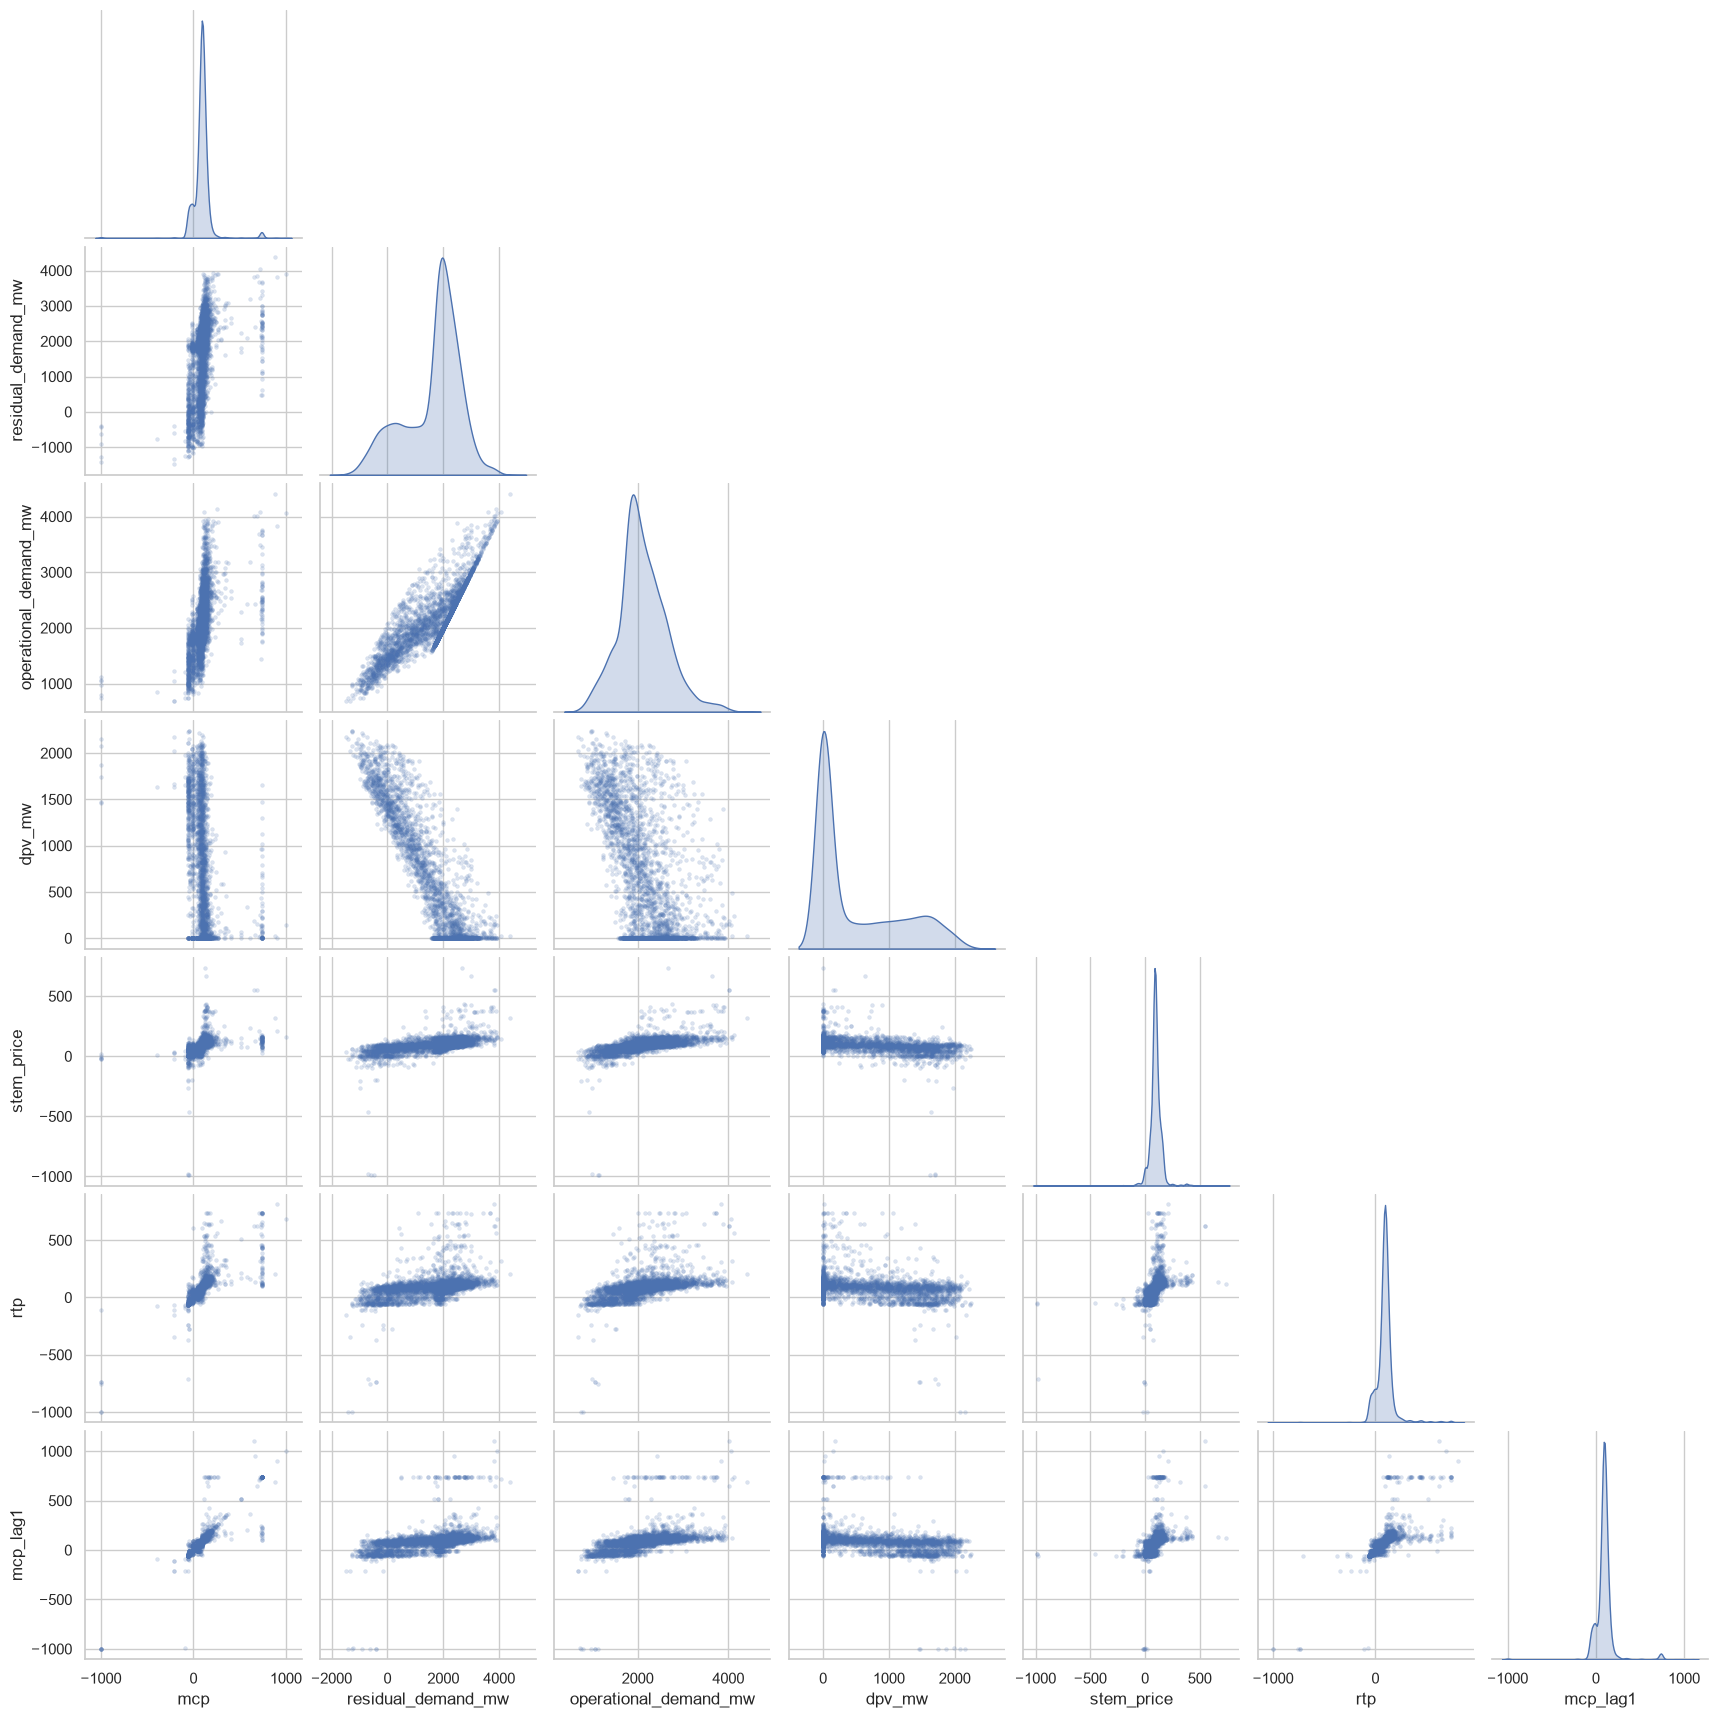

In [9]:
sample = df.sample(20_000, random_state=7)
pairs = [
    ("residual_demand_mw", "residual demand"),
    ("operational_demand_mw", "operational demand"),
    ("dpv_mw", "distributed PV"),
    ("stem_price", "STEM price"),
    ("rtp", "RTP (same interval — leakage)"),
    ("scada_mw", "SCADA MW"),
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (xcol, title) in zip(axes.ravel(), pairs):
    sns.scatterplot(x=sample[xcol], y=sample["mcp"], ax=ax, s=8, alpha=0.15, edgecolor=None)
    ax.set_title(title)
plt.tight_layout()

key = ["mcp", "residual_demand_mw", "operational_demand_mw", "dpv_mw", "stem_price", "rtp", "mcp_lag1"]
sns.pairplot(
    sample[key].sample(4000, random_state=7),
    corner=True,
    diag_kind="kde",
    plot_kws={"s": 8, "alpha": 0.2, "edgecolor": None},
)

## Collinear blocks

Demand/generation is one redundant block. FCAS is a different market — related in stress periods, not a substitute for residual demand.

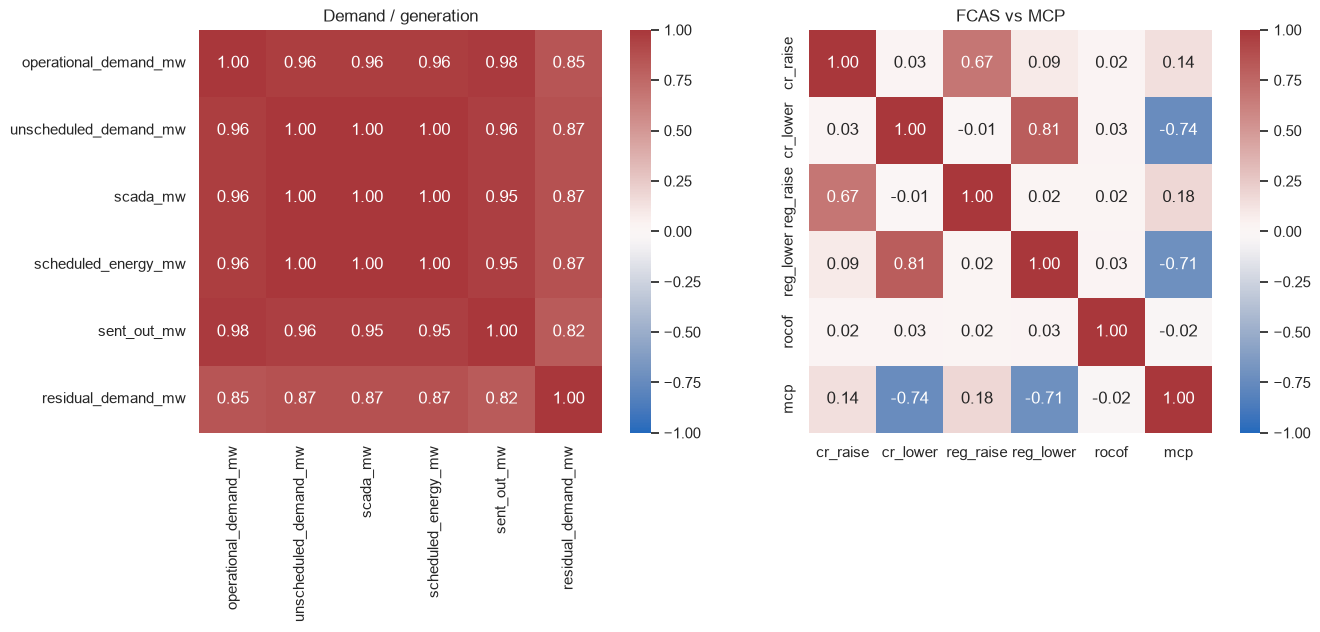

In [10]:
demand_block = [
    "operational_demand_mw", "unscheduled_demand_mw", "scada_mw",
    "scheduled_energy_mw", "sent_out_mw", "residual_demand_mw",
]
fcas_block = ["cr_raise", "cr_lower", "reg_raise", "reg_lower", "rocof", "mcp"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(df[demand_block].corr(method="spearman"), ax=axes[0], cmap="vlag",
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True)
axes[0].set_title("Demand / generation")
sns.heatmap(df[fcas_block].corr(method="spearman"), ax=axes[1], cmap="vlag",
            center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True)
axes[1].set_title("FCAS vs MCP")
plt.tight_layout()

## Per-column interpretation (data-driven neighbours)

For every column: missingness, distribution, Spearman with MCP, and the six closest Spearman neighbours. Written domain notes for each column are in `reports/eda/feature_interpretation.md` after you run `python scripts/explore_panel.py`.

In [11]:
rows = []
for col in df.columns:
    s = df[col]
    rec = {
        "column": col,
        "dtype": str(s.dtype),
        "missing_%": 100 * s.isna().mean(),
        "n_unique": s.nunique(dropna=True),
    }
    if col in num.columns:
        rec.update({
            "mean": num[col].mean(),
            "median": num[col].median(),
            "std": num[col].std(),
            "min": num[col].min(),
            "max": num[col].max(),
            "skew": num[col].skew(),
            "spearman_mcp": spearman.loc["mcp", col] if col in spearman.index else np.nan,
            "pearson_mcp": pearson.loc["mcp", col] if col in pearson.index else np.nan,
        })
        neigh = (
            spearman[col].drop(labels=[col], errors="ignore")
            .abs().sort_values(ascending=False).head(4)
        )
        rec["top_neighbours"] = ", ".join(
            f"{n} ({spearman.loc[col, n]:+.2f})" for n in neigh.index
        )
    rows.append(rec)

profile = pd.DataFrame(rows)
display(
    profile.style.format({
        "missing_%": "{:.2f}",
        "mean": "{:.3g}",
        "median": "{:.3g}",
        "std": "{:.3g}",
        "min": "{:.3g}",
        "max": "{:.3g}",
        "skew": "{:.2f}",
        "spearman_mcp": "{:.3f}",
        "pearson_mcp": "{:.3f}",
    }, na_rep="—")
)

,column,dtype,missing_%,n_unique,mean,median,std,min,max,skew,spearman_mcp,pearson_mcp,top_neighbours
0,interval_end,datetime64[us],0.00,302964,—,—,—,—,—,—,—,—,—
1,mcp,float64,0.00,20820,89,91,113,-1e+03,1.1e+03,1.06,1.000,1.000,"mcp_lag1 (+0.96), rtp (+0.91), mcp_lag6 (+0.87), mcp_lag12 (+0.79)"
2,cr_raise,float64,0.00,14639,30.1,0,129,0,2.4e+03,10.14,0.143,0.491,"reg_raise (+0.67), year (-0.23), stem_offer_mwh (-0.20), mcp (+0.14)"
3,cr_lower,float64,0.00,13191,22.1,0,70,0,2.04e+03,13.33,-0.739,-0.472,"reg_lower (+0.81), mcp (-0.74), mcp_lag1 (-0.71), rtp (-0.68)"
4,reg_raise,float64,0.00,9166,16.6,0,107,0,2.4e+03,12.09,0.180,0.540,"cr_raise (+0.67), mcp (+0.18), mcp_lag1 (+0.15), stem_offer_mwh (-0.15)"
5,reg_lower,float64,0.00,15789,27.8,1.06,76.2,0,2.04e+03,11.75,-0.713,-0.481,"cr_lower (+0.81), mcp (-0.71), mcp_lag1 (-0.69), stem_bid_mwh (-0.67)"
6,rocof,float64,0.00,3,0.000994,0,0.545,0,300,550.42,-0.023,-0.000,"year (-0.03), cr_lower (+0.03), reg_lower (+0.03), stem_bid_mwh (-0.03)"
7,operational_demand_mw,float64,0.00,152908,2.09e+03,2.04e+03,525,509,4.48e+03,0.40,0.650,0.448,"sent_out_mw (+0.98), sent_out_mwh (+0.98), unscheduled_demand_mw (+0.96), scada_mw (+0.96)"
8,unscheduled_demand_mw,float64,0.00,156970,2.01e+03,1.96e+03,557,354,4.48e+03,0.30,0.620,0.430,"scada_mw (+1.00), scada_mwh (+1.00), scheduled_energy_mw (+1.00), operational_demand_mw (+0.96)"
9,operational_withdrawal_mw,float64,0.00,44159,-78.3,-12.6,131,-1.16e+03,-0.38,-2.53,0.111,0.036,"year (-0.48), dpv_mw_30min (-0.40), unscheduled_demand_mw (+0.39), scada_mw (+0.39)"


## Modelling takeaways

1. **Split features by horizon.** `mcp_lag1` is the strongest 5-minute-ahead signal and is not available day-ahead.
2. **Do not use same-interval `rtp` to predict MCP** — it is the 30-minute energy price from the same market.
3. **Collapse demand/generation.** Keep `residual_demand_mw` (or demand + DPV) and at most one of SCADA / scheduled / sent-out. Drop `sent_out_mwh` and `scada_mwh`.
4. **`stem_price` is the clean forward price** already known before real-time dispatch.
5. **Encode calendar cyclically or as categoricals** (`hour`, `dow`, `month`). `year` is a regime dummy; 2023 and 2026 are partial years.
6. **FCAS is a different market.** Lag it, or model it separately.
7. **Score tails properly.** MCP kurtosis is huge — pinball / CRPS / coverage, not RMSE alone.
8. **Only material holes:** `dpv_mw_30min` (~5%) and `sent_out_*` (~3%). Prefer 5-minute `dpv_mw`.